# Exploratory Data Analysis - EDA


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import apply_balance, top_n_grams
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


load train dataset

In [3]:
sample_train = pd.read_csv(r'data/samples/sample_train.csv', dtype=str, quoting=0)
sample_train.head()

,target,title_review,content_review
0,2,"Good tool, good price",I received the tool in a timely fashion.Assemb...
1,1,Not what I expected!,"This toy has alot of activities, but is not a ..."
2,1,Not so great,"I wanted this hair wax for a while, and once I..."
3,1,"Great hardware, but the PC software is terrible",The hardware functionality is excellent for ou...
4,2,A must for anyone who cooks and bakes!!!,To say that i am pleased with my kitchenaid ar...


In [4]:
sample_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   target          80000 non-null  str  
 1   title_review    79994 non-null  str  
 2   content_review  80000 non-null  str  
dtypes: str(3)
memory usage: 1.8 MB


Check Missing Values


In [5]:
sample_train.isna().sum()

target            0
title_review      6
content_review    0
dtype: int64

In [6]:
sample_train.dropna(inplace=True)
sample_train.isna().sum()

target            0
title_review      0
content_review    0
dtype: int64

check duplications

In [7]:
sample_train.duplicated().sum()

np.int64(0)

Check Class Balance

In [8]:
sample_train.value_counts('target')

target
1    40008
2    39986
Name: count, dtype: int64

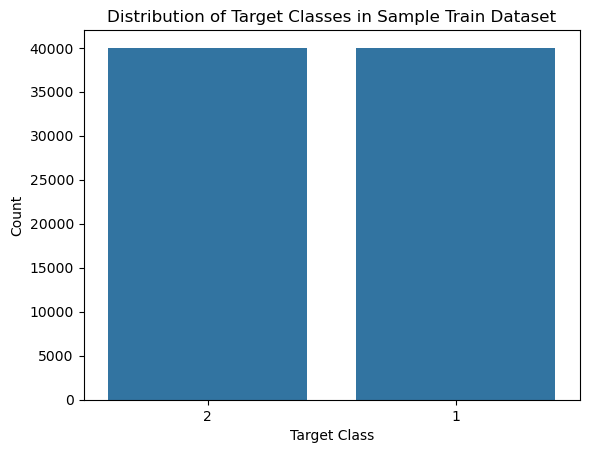

In [9]:
sns.countplot(x='target', data=sample_train)
plt.title('Distribution of Target Classes in Sample Train Dataset')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

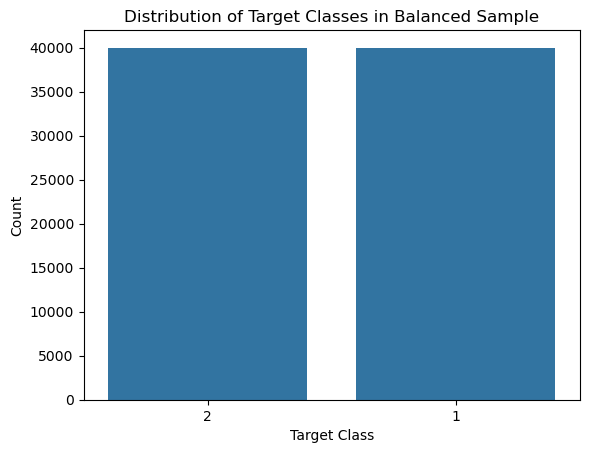

In [10]:
balanced_sample_train = apply_balance(sample_train, target_col='target', random_state=42)
sns.countplot(x='target', data=balanced_sample_train)
plt.title('Distribution of Target Classes in Balanced Sample')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

In [11]:
balanced_sample_train.value_counts('target')

target
2    39986
1    39986
Name: count, dtype: int64

Text Analysis

In [12]:
balanced_sample_train['char_count'] = balanced_sample_train['content_review'].str.len()
balanced_sample_train.head()

,target,title_review,content_review,char_count
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586
1,1,not so great,I'm using this book in an introductory organic...,570
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198


In [13]:
balanced_sample_train['word_count'] = balanced_sample_train['content_review'].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)
balanced_sample_train.head()

,target,title_review,content_review,char_count,word_count
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108
1,1,not so great,I'm using this book in an introductory organic...,570,88
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38


In [14]:
balanced_sample_train[['char_count','word_count']].describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,79972.0,404.347584,234.072075,25.0,207.0,354.0,564.0,1005.0
word_count,79972.0,74.022608,42.263353,6.0,38.0,65.0,103.0,209.0


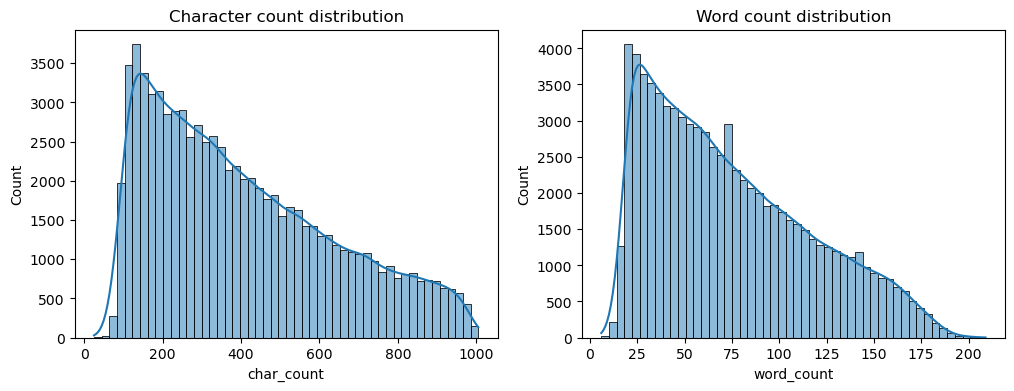

In [15]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(balanced_sample_train['char_count'], bins=50, kde=True)
plt.title('Character count distribution')
plt.subplot(1,2,2)
sns.histplot(balanced_sample_train['word_count'], bins=50, kde=True)
plt.title('Word count distribution')
plt.show()

save balanced_sample_train dataset

In [16]:
balanced_sample_train.to_csv(r'data/balanced/balanced_sample_train.csv', index=False)
print("Balanced sample train dataset saved to 'data/balanced/balanced_sample_train.csv'")

Balanced sample train dataset saved to 'data/balanced/balanced_sample_train.csv'
